In [ ]:
# Getting IBM backend connected

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from time import sleep
import dynamic_broadcast as db
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=200)
np.set_printoptions(precision=3, suppress=True)

service = QiskitRuntimeService(name="mprest1")



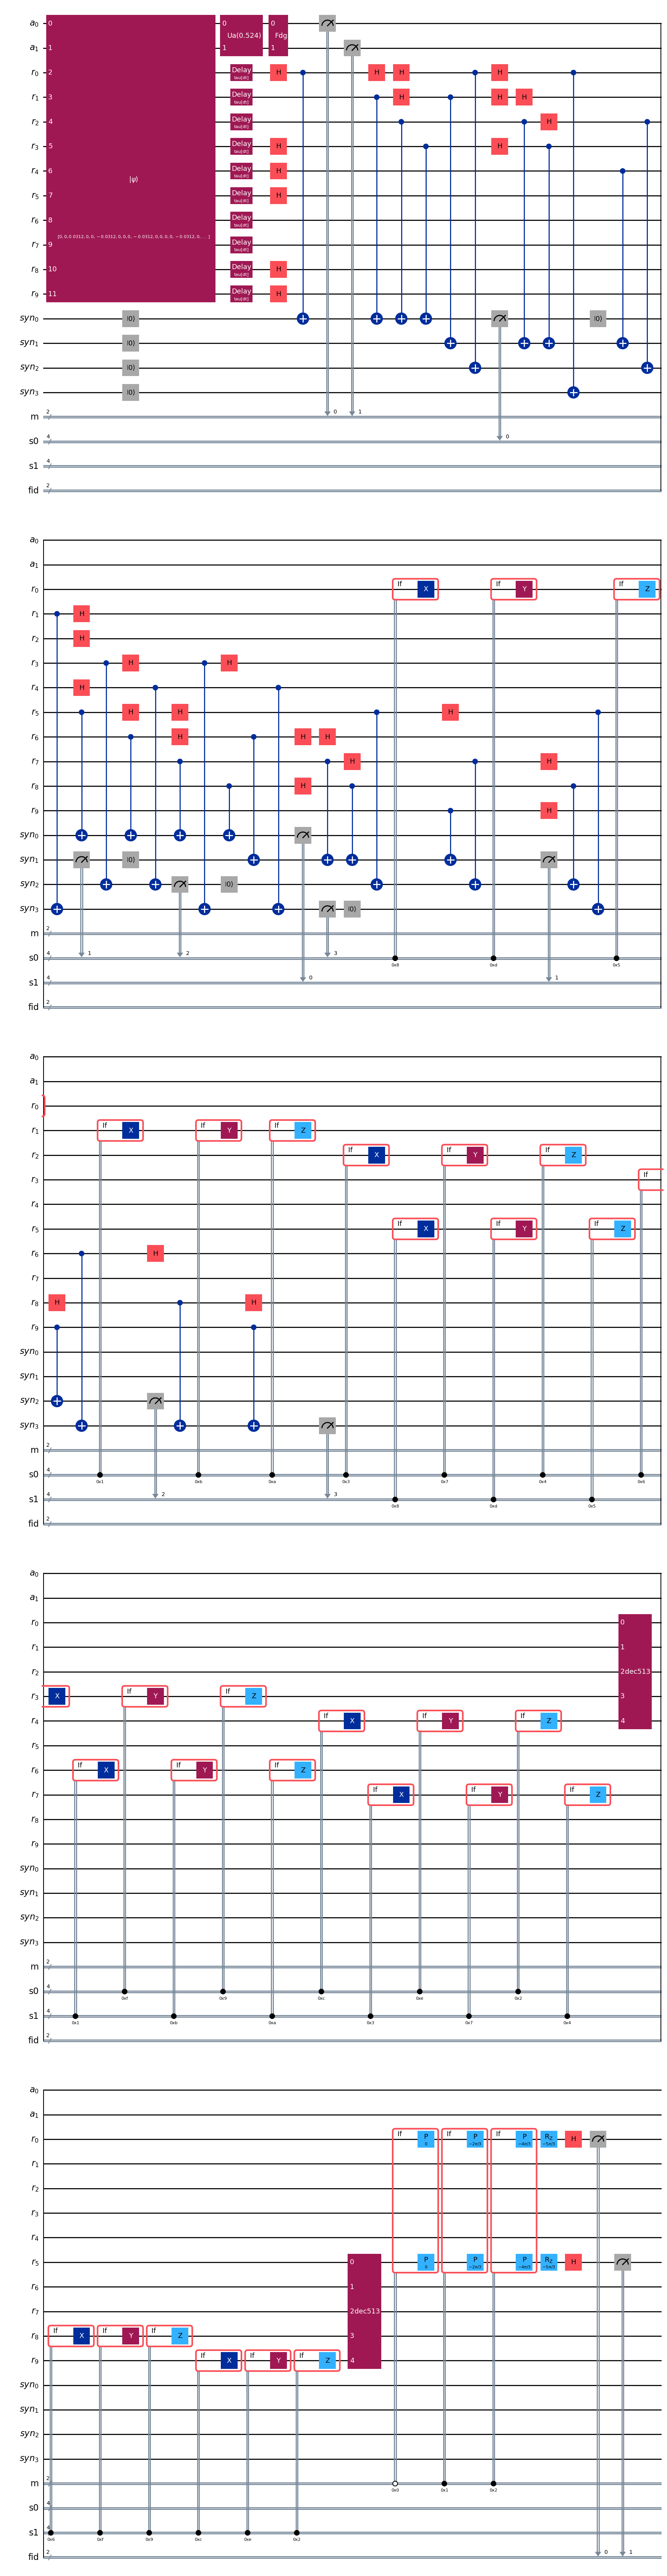

In [2]:
# Testing functions in library with a parameterized delay on receiver qubits
thetas = [np.pi/6]  # The sender phase angles
N_receivers = 2
tau_values = np.array([0, 500, 1000, 2000])  # small sweep in backend dt units

circuit = db.generate_qiskit_circuit(1, N_receivers, thetas, use_receiver_qec_513=True)
circuit, reg_name, phi = db.add_fidelity(circuit, N=N_receivers, thetas=thetas)

tau_param = next((p for p in circuit.parameters if p.name == "tau"), None)
if tau_param is None:
    raise ValueError("Expected a symbolic 'tau' parameter in the circuit.")

bound_circuits = [circuit.assign_parameters({tau_param: int(tau)}) for tau in tau_values]

circuit.draw("mpl")


In [3]:
# Constructing the primitive and running a tau sweep
backend = service.least_busy(simulator=False, operational=True)
print(f"Backend selected: {backend}")

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuits = [pm.run(c) for c in bound_circuits]

sampler = Sampler(mode=backend)
pubs = [(isa_circuit, None) for isa_circuit in isa_circuits]
job = sampler.run(pubs, shots=1024)
print(f">>> Job ID: {job.job_id()}")
sleep(10)
print(f">>> Job Status: {job.status()}")


Backend selected: <IBMBackend('ibm_marrakesh')>
>>> Job ID: d7b74815a5qc73dn408g
>>> Job Status: RUNNING


In [4]:
# Extracting and displaying the results for each tau
results = job.result()
fidelity_sweep = {}

for tau, pub_result in zip(tau_values, results):
    counts = getattr(pub_result.data, reg_name).get_counts()
    shots = sum(counts.values())

    fidelities = []
    for i in range(N_receivers):
        p0 = sum(v for bitstr, v in counts.items() if bitstr[::-1][i] == "0") / shots
        fidelities.append(p0)

    fidelity_sweep[int(tau)] = fidelities

for tau, fidelities in fidelity_sweep.items():
    print(f"tau={tau}: fidelities={fidelities}")



tau=0: fidelities=[0.4931640625, 0.4794921875]
tau=500: fidelities=[0.5146484375, 0.466796875]
tau=1000: fidelities=[0.484375, 0.4814453125]
tau=2000: fidelities=[0.4794921875, 0.5146484375]
